In [ ]:
from a_NN_Samplers_and_VI_algo import*

from B_1_extensions_MMDkernelWidth import (
    MMD_fixed, MMD_median, MMD_multiscale, MMD_multiscale_median,
    median_bandwidth, VI_Brownian_MMD,
)

In [3]:
def basis_functions(x: np.ndarray) -> np.ndarray:
    return np.stack([np.sin(2*np.pi*x)], axis=1)


def generate_data(N: int, a: float, w_true: np.ndarray, seed: int = 0):
    rng = np.random.default_rng(seed)
    x = rng.uniform(1, 3, size=N)
    Phi = basis_functions(x)  # (N, 3)
    noise = rng.normal(0.0, np.sqrt(a), size=N)
    y = Phi @ w_true + noise
    return x, Phi, y
seed1 = 13
w_true = np.array([2])

In [ ]:
def plot_posterior_predictive(model, start_prediction,sampler,mu,x_train,y_train,x_plot,latent_fn=None,n_plot_samples=30,drift = False):
    """
    Plot posterior predictive using samples from q(theta).
    """


    x_plot_t = torch.as_tensor(x_plot, dtype=mu.dtype).reshape(-1, 1)


    theta_samples = sampler.sample_q_endpoints(mu, detach_from_mu=True,drift=drift)

  
    with torch.no_grad():
        y_samples = model.forward_theta_batch(theta_samples, x_plot_t)
        y_mean = y_samples.mean(dim=0)
        y_std = y_samples.std(dim=0)


    plt.figure(figsize=(7, 5))


    plt.scatter(x_train, y_train, color="tab:blue", label="data", zorder=3)

   
    if latent_fn is not None:
        plt.plot(
            x_plot,
            latent_fn(x_plot),
            color="red",
            linewidth=2,
            label="Latent function",
        )

   
    for i in range(min(n_plot_samples, y_samples.shape[0])):
        plt.plot(
            x_plot,
            y_samples[i].cpu().numpy(),
            color="purple",
            alpha=0.15,
            linewidth=1,
        )


    plt.plot(
        x_plot,
        y_mean.cpu().numpy(),
        color="black",
        linewidth=2,
        label="Posterior mean",
    )

    plt.fill_between(
        x_plot.flatten(),
        (y_mean - 2 * y_std).cpu().numpy(),
        (y_mean + 2 * y_std).cpu().numpy(),
        color="gray",
        alpha=0.3,
        label="±2 std",
    )
    plt.plot(x_plot, start_prediction, label='start model')

    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Posterior predictive (sampling from q)")
    plt.tight_layout()
    plt.show()

# Data points

In [5]:
# Raw data
x_data = np.linspace(1, 5, 5, dtype=np.float64)
y_data = np.sin(2*x_data) + np.cos(4*x_data)

# Normalization stats
x_mean, x_std = x_data.mean(), x_data.std()
y_mean, y_std = y_data.mean(), y_data.std()

# Normalized versions (used for all training / VI internals)
x_data_n = (x_data - x_mean) / x_std
y_data_n = (y_data - y_mean) / y_std

# Tensors that go into the network are NORMALIZED
x_tensor = torch.from_numpy(x_data_n).view(-1, 1)
y_tensor = torch.from_numpy(y_data_n).view(-1, 1)

# Plotting grid: keep original for x-axis, normalized for the network
x_grid_np = np.linspace(0, 6, 1000, dtype=np.float64)
x_grid_n  = (x_grid_np - x_mean) / x_std
x_grid_tensor = torch.from_numpy(x_grid_n).view(-1, 1)   # normalized input


In [6]:
activation_func = "tanh"
N_hidden = 16
N_hidden2 = 16
N_sample = 100
BM_walk_len = 50
BM_step_size = 1e-4 # remember to square it!
G_init_sigma = 0.1
covariance = "full" #full or diag





#model = Net_1_Layer(N_hidden, activation_type = activation_func).double()
model = Net_2_Layer(N_hidden, N_hidden2 , activation_type = activation_func).double()


#model_VI = NeuralNetworkModel([1, N_hidden, 1], activation_type = activation_func)
model_VI = NeuralNetworkModel([1, N_hidden, N_hidden2, 1], activation_type = activation_func)

dim = model_VI.theta_dim
loss_fn = Losses_SSE(model_VI, x_data_n, y_data_n)
metric = RiemannianMetric(loss_fn)
ratio_net = RatioNet(dim).to(dtype=torch.float64) #for VAN


theta = Train_Net(model, 20000, x_tensor, y_tensor, lr=0.001)

sampler = Brownian_sampler(metric, walk_len=BM_walk_len, step_size = BM_step_size, n_samples=N_sample)# prior_mean=theta.detach().clone(), prior_std=0.5)


Loss zero at [1399/20000], Loss: 0.0000
step [20000/20000], Loss: 0.0000


In [ ]:

with torch.no_grad():
    X_q0 = sampler.sample_q_endpoints(theta, detach_from_mu=True)
    X_p0 = sampler.sample_prior(theta.dtype, theta.device, dim)
    med0 = median_bandwidth(X_q0, X_p0)
print(f"Median pairwise distance at init: {med0:.3f}")
print(f"  (so a single-scale MMD with sigma << {med0:.1f} will saturate to 0,")
print(f"   and sigma >> {med0:.1f} will be ~constant. Useful range ~[{med0/4:.1f}, {4*med0:.1f}].)")


FIXED_SIGMAS = {
    "sigma=0.1 (too small)" : 0.1,
    "sigma=1.0 (small)"     : 1.0,
    f"sigma={med0:.1f} (~median)": med0,
    "sigma=50.0 (large)"    : 50.0,
    "sigma=500.0 (too large)": 500.0,
}
MIX_SIGMAS = [0.5, 2.0, med0, med0 * 2, med0 * 4]

def make_strategies():
    s = {}
    for label, sig in FIXED_SIGMAS.items():
        s[label] = (lambda Xq, Xp, _sig=sig: MMD_fixed(Xq, Xp, _sig))
    s["multi-scale (fixed ladder)"] = (
        lambda Xq, Xp: MMD_multiscale(Xq, Xp, MIX_SIGMAS)
    )
    s["adaptive median"] = MMD_median
    s["multi-scale median (auto)"] = (
        lambda Xq, Xp: MMD_multiscale_median(Xq, Xp, scales=(0.25, 0.5, 1.0, 2.0, 4.0))
    )
    return s

STRATEGIES = make_strategies()


SWEEP_STRATEGIES = {
    "sigma=0.1 (too small)"        : STRATEGIES["sigma=0.1 (too small)"],
    "sigma=1.0 (small)"        : STRATEGIES["sigma=1.0 (small)"],
    f"sigma={med0:.1f} (~median)"  : STRATEGIES[f"sigma={med0:.1f} (~median)"],
    "sigma=500.0 (too large)"      : STRATEGIES["sigma=500.0 (too large)"],
    "multi-scale median (auto)"    : STRATEGIES["multi-scale median (auto)"],
}


Median pairwise distance at init: 19.201
  (so a single-scale MMD with sigma << 19.2 will saturate to 0,
   and sigma >> 19.2 will be ~constant. Useful range ~[4.8, 76.8].)


In [ ]:



N_OPT_STEPS = 100
SEED        = 0
LR_ADAM     = 1e-2
LR_SGD      = 1e-2

BETAS = [1, 10, 100, 500]

OPTIMIZERS = {
    "SGD" : dict(optimizer="sgd",  lr_VI=LR_SGD, sgd_momentum=0.0),
    "Adam": dict(optimizer="adam", lr_VI=LR_ADAM),
}

results = {} 

for strat_label, mmd_fn in SWEEP_STRATEGIES.items():
    for beta in BETAS:
        for opt_label, opt_kwargs in OPTIMIZERS.items():
            print(f"\n=== {strat_label} | β={beta} | {opt_label} ===")
            mu_end, mu_hist, obj_hist, exp_hist, kl_hist = VI_Brownian_MMD(
                mu_start    = theta.detach().clone(),
                loss        = loss_fn,
                sampler     = sampler,
                mmd_fn      = mmd_fn,
                mmd_label   = strat_label,
                n_opt_steps = N_OPT_STEPS,
                beta        = beta,                
                seed        = SEED,
                drift       = False,
                verbose_every = 50,
                **opt_kwargs,
            )
            with torch.no_grad():
                theta_samples = sampler.sample_q_endpoints(mu_end, detach_from_mu=True)
                y_samples_n   = model_VI.forward_theta_batch(theta_samples, x_grid_tensor)
            y_samples = y_samples_n.cpu().numpy() * y_std + y_mean
            m = y_samples.mean(axis=0)
            s = y_samples.std (axis=0)

            # Track ||mu|| trajectory
            mu_norms = np.linalg.norm(mu_hist, axis=1)

            # Key includes beta!
            results[(strat_label, beta, opt_label)] = dict(
                mu_end=mu_end, obj=obj_hist, exp=exp_hist, kl=kl_hist,
                y_samples=y_samples, m=m, s=s,
                mu_norms=mu_norms,
            )



=== sigma=0.1 (too small) | β=1 | SGD ===
  [diag] ||∇MMD|| = 5.092e-55, ||∇E[L]|| = 6.159e-01, ratio = 6.16e+29
  [sigma=0.1 (too small) | sgd] iter   50 | obj=0.2597 | E[L]=0.2397 | MMD=2.0000e-02 | ||mu||=7.188
  [sigma=0.1 (too small) | sgd] iter  100 | obj=0.2450 | E[L]=0.2250 | MMD=2.0000e-02 | ||mu||=7.195

=== sigma=0.1 (too small) | β=1 | Adam ===
  [diag] ||∇MMD|| = 5.092e-55, ||∇E[L]|| = 6.159e-01, ratio = 6.16e+29
  [sigma=0.1 (too small) | adam] iter   50 | obj=0.2098 | E[L]=0.1898 | MMD=2.0000e-02 | ||mu||=7.422
  [sigma=0.1 (too small) | adam] iter  100 | obj=0.1869 | E[L]=0.1669 | MMD=2.0000e-02 | ||mu||=7.607

=== sigma=0.1 (too small) | β=10 | SGD ===
  [diag] ||∇MMD|| = 5.092e-55, ||∇E[L]|| = 6.159e-01, ratio = 6.16e+29
  [sigma=0.1 (too small) | sgd] iter   50 | obj=0.4397 | E[L]=0.2397 | MMD=2.0000e-02 | ||mu||=7.188
  [sigma=0.1 (too small) | sgd] iter  100 | obj=0.4250 | E[L]=0.2250 | MMD=2.0000e-02 | ||mu||=7.195

=== sigma=0.1 (too small) | β=10 | Adam ===
  [

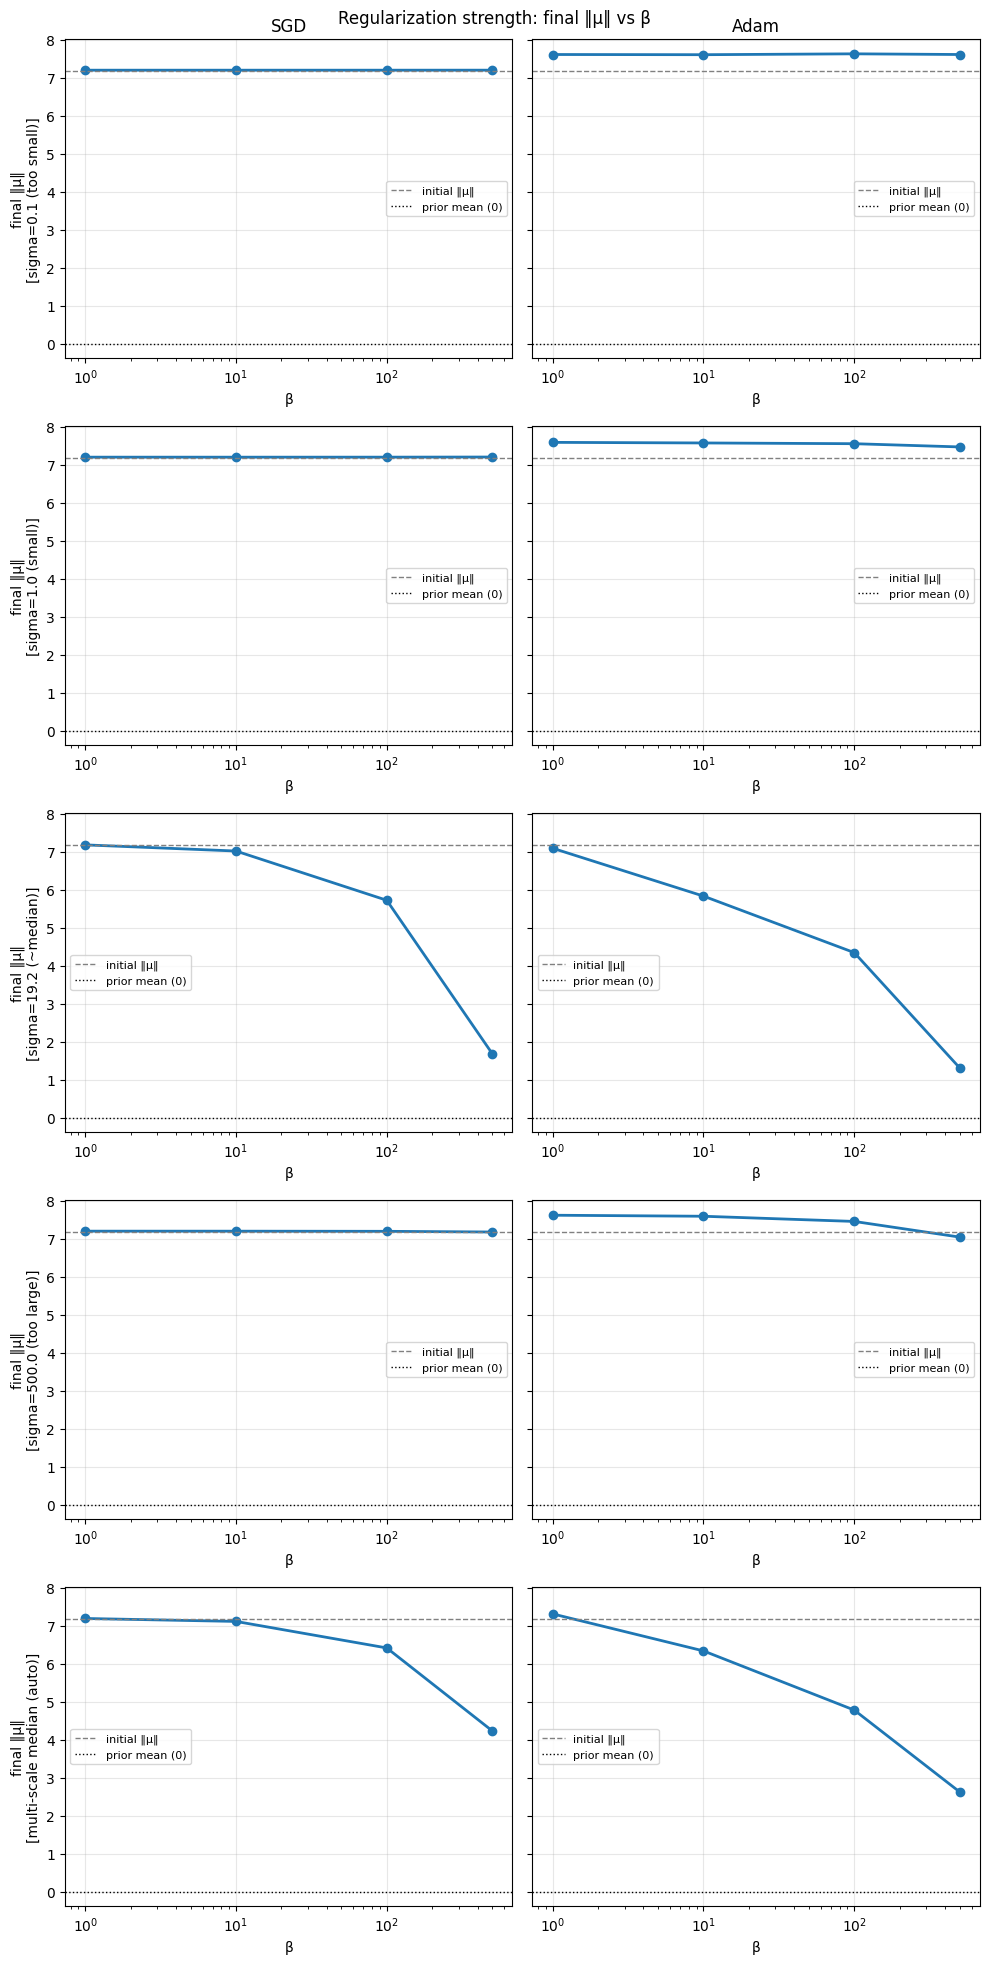

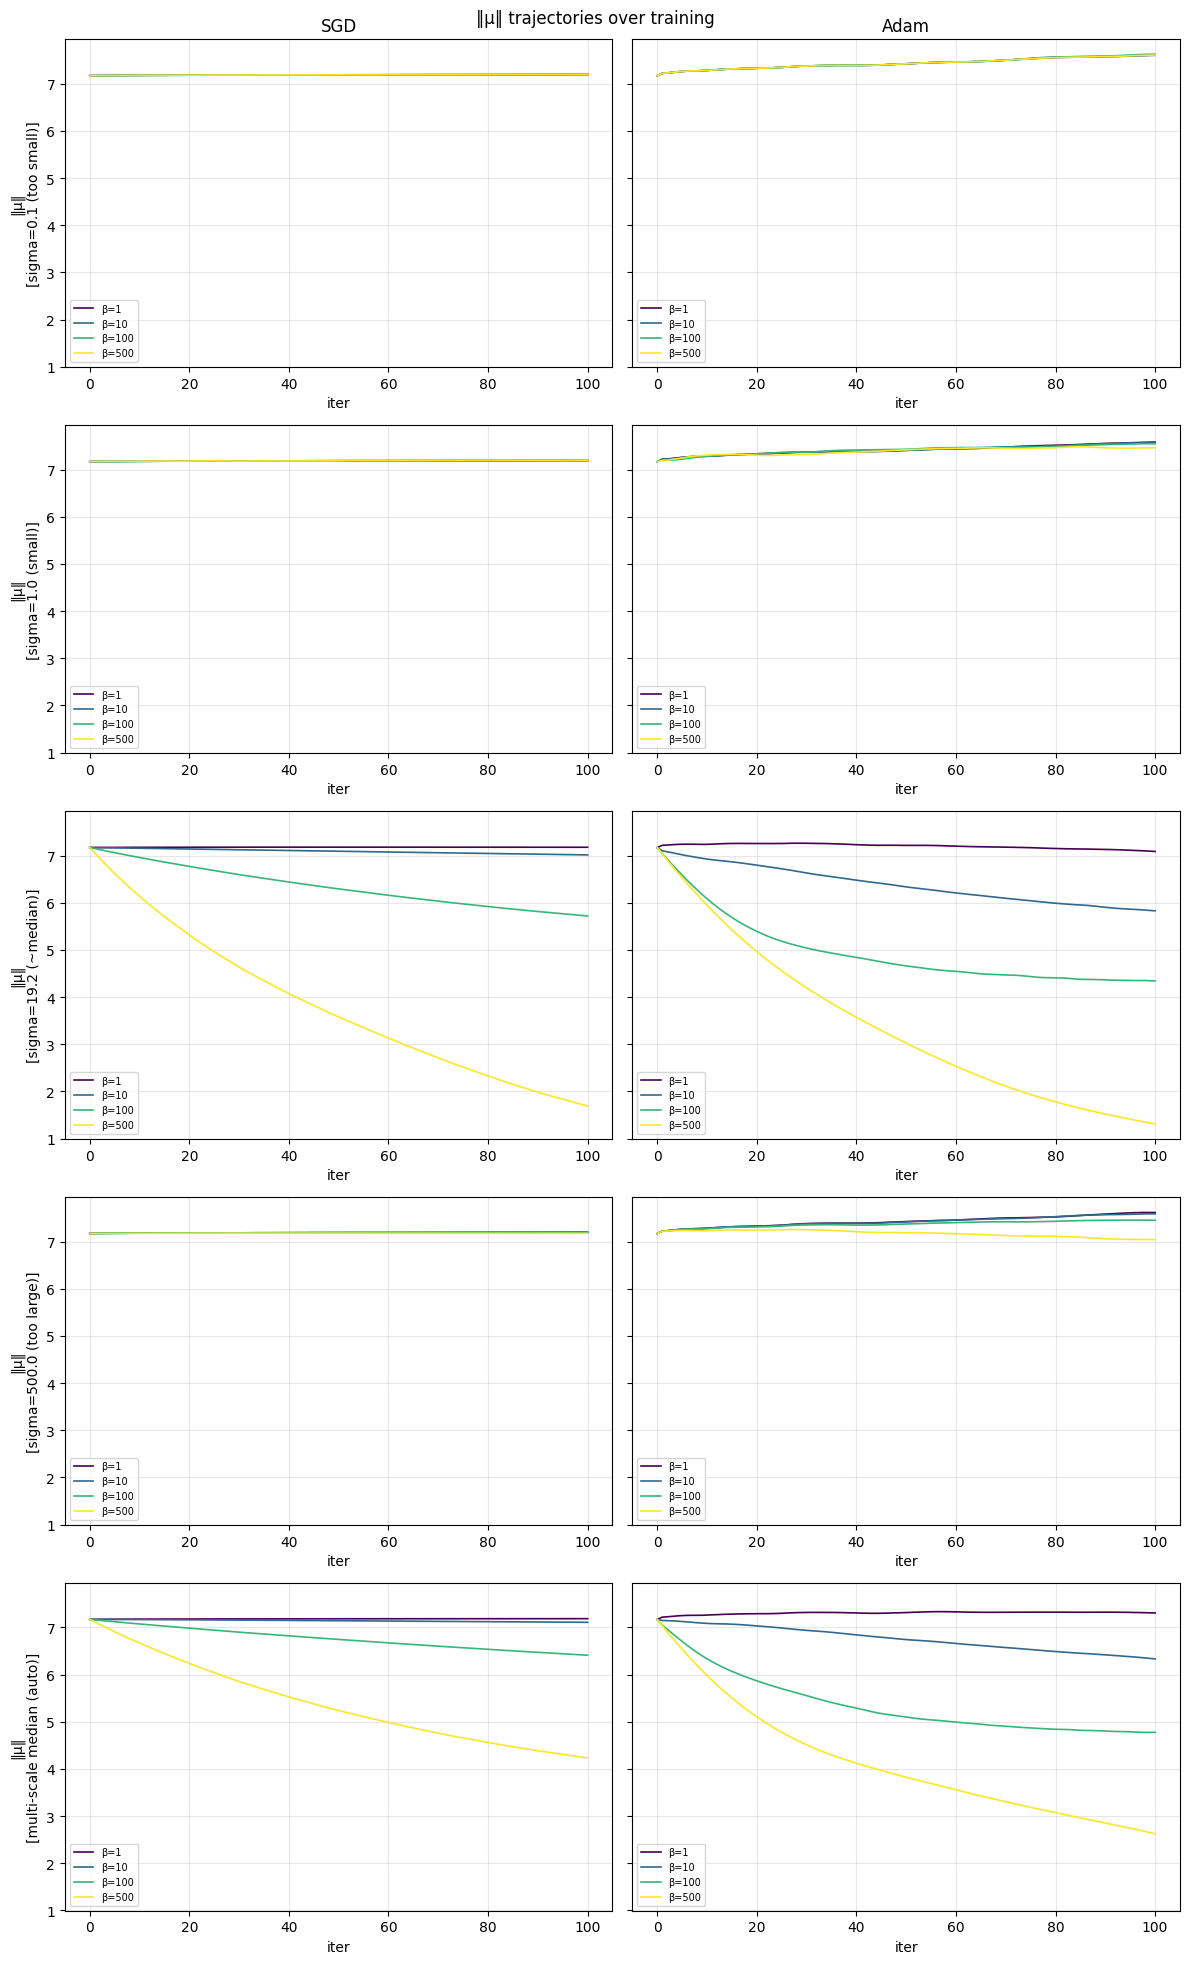

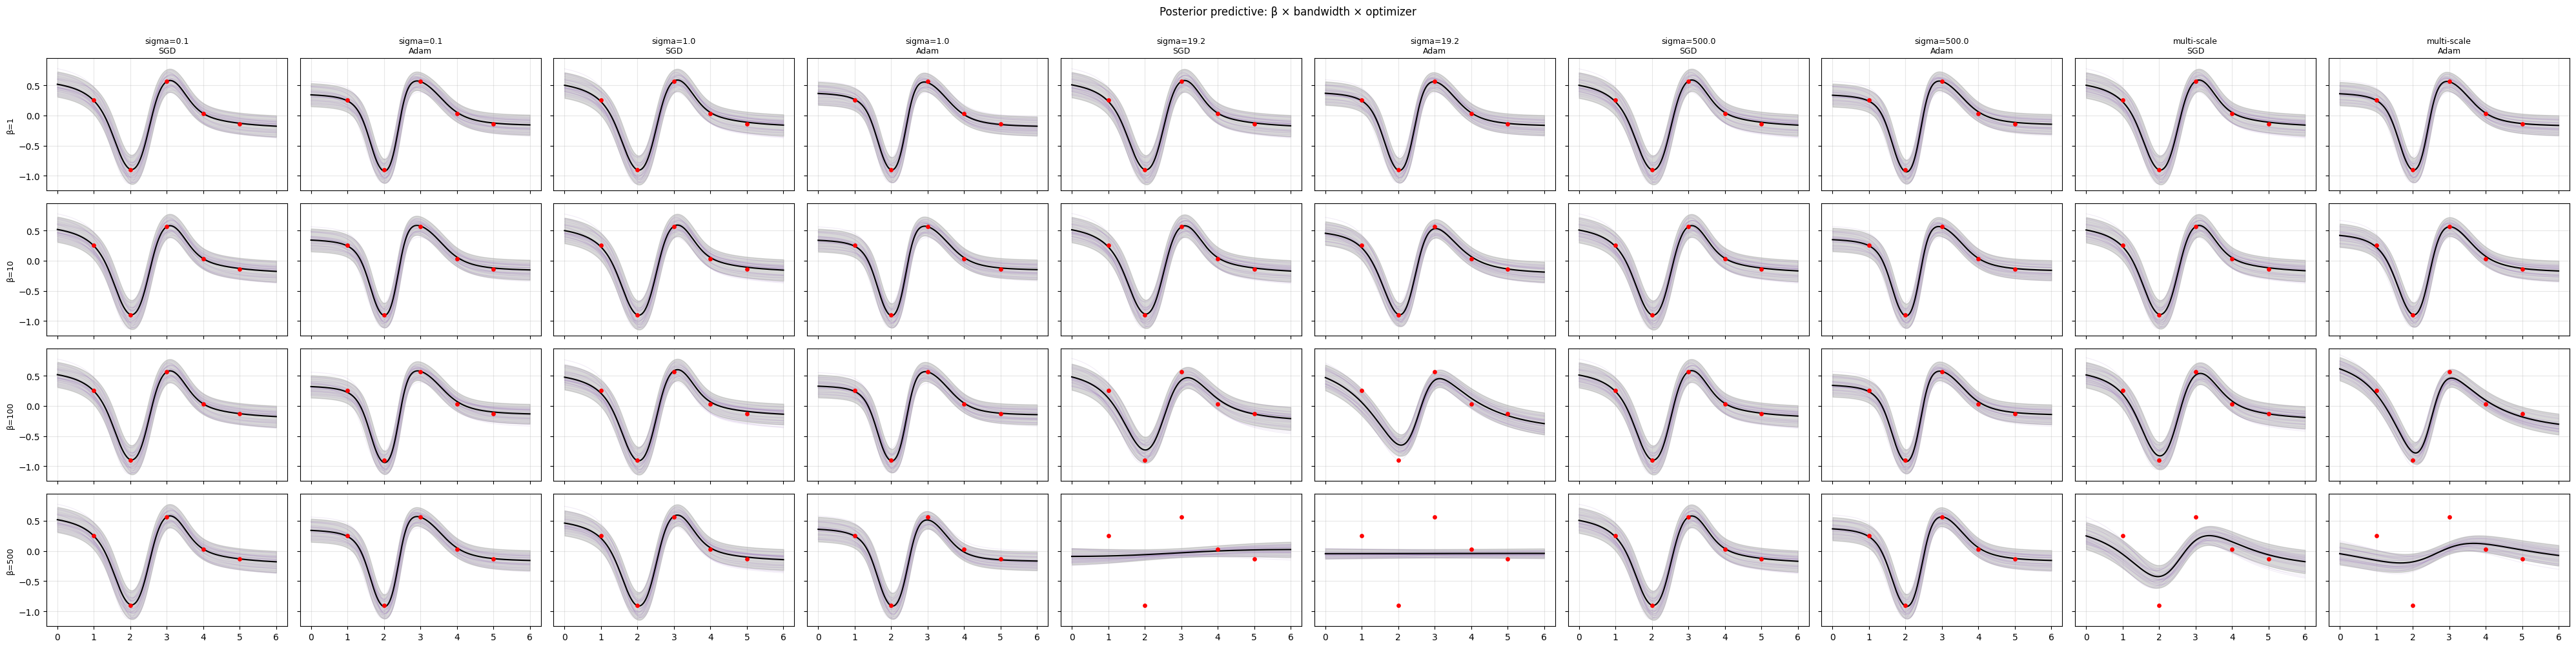


strategy                            β  optim    init‖μ‖   final‖μ‖   final E[L]    final MMD
sigma=0.1 (too small)               1    SGD      7.170      7.195       0.2250   2.0000e-02
sigma=0.1 (too small)               1   Adam      7.170      7.607       0.1669   2.0000e-02
sigma=0.1 (too small)              10    SGD      7.170      7.195       0.2250   2.0000e-02
sigma=0.1 (too small)              10   Adam      7.170      7.602       0.1653   2.0000e-02
sigma=0.1 (too small)             100    SGD      7.170      7.195       0.2250   2.0000e-02
sigma=0.1 (too small)             100   Adam      7.170      7.625       0.1689   2.0000e-02
sigma=0.1 (too small)             500    SGD      7.170      7.195       0.2252   2.0000e-02
sigma=0.1 (too small)             500   Adam      7.170      7.607       0.1669   2.0000e-02
sigma=1.0 (small)                   1    SGD      7.170      7.195       0.2245   2.2214e-01
sigma=1.0 (small)                   1   Adam      7.170      7.584   

In [ ]:

xg = x_grid_np
strat_labels = list(SWEEP_STRATEGIES.keys())
opt_labels   = list(OPTIMIZERS.keys())
n_betas      = len(BETAS)

# 3a. The "regularization curve": final ||mu|| vs beta, one panel per (strategy, optim)
fig, axes = plt.subplots(len(strat_labels), len(opt_labels),
                         figsize=(5*len(opt_labels), 4*len(strat_labels)),
                         sharey=True, squeeze=False)

for i, strat in enumerate(strat_labels):
    for j, opt in enumerate(opt_labels):
        ax = axes[i, j]
        final_mu_norms = [results[(strat, b, opt)]["mu_norms"][-1] for b in BETAS]
        ax.plot(BETAS, final_mu_norms, marker="o", lw=2)
        ax.set_xscale("log")
        ax.axhline(theta.norm().item(), color="gray", ls="--", lw=1, label="initial ‖μ‖")
        ax.axhline(0, color="black", ls=":", lw=1, label="prior mean (0)")
        ax.set_xlabel("β")
        if j == 0:
            ax.set_ylabel(f"final ‖μ‖\n[{strat}]")
        if i == 0:
            ax.set_title(opt)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
fig.suptitle("Regularization strength: final ‖μ‖ vs β")
plt.tight_layout()
plt.show()


# 3b. ||μ|| trajectories over training, colored by β
fig, axes = plt.subplots(len(strat_labels), len(opt_labels),
                         figsize=(6*len(opt_labels), 4*len(strat_labels)),
                         sharey=True, squeeze=False)
cmap = plt.cm.viridis(np.linspace(0, 1, n_betas))

for i, strat in enumerate(strat_labels):
    for j, opt in enumerate(opt_labels):
        ax = axes[i, j]
        for k, beta in enumerate(BETAS):
            r = results[(strat, beta, opt)]
            ax.plot(r["mu_norms"], color=cmap[k], label=f"β={beta}", lw=1.2)
        ax.set_xlabel("iter")
        if j == 0:
            ax.set_ylabel(f"‖μ‖\n[{strat}]")
        if i == 0:
            ax.set_title(opt)
        ax.legend(fontsize=7, loc="best")
        ax.grid(True, alpha=0.3)
fig.suptitle("‖μ‖ trajectories over training")
plt.tight_layout()
plt.show()


# 3c. Posterior predictive grid: rows = beta, cols = (strategy x optimizer)
n_show = 30
fig, axes = plt.subplots(n_betas, len(strat_labels)*len(opt_labels),
                         figsize=(4*len(strat_labels)*len(opt_labels), 2.5*n_betas),
                         sharex=True, sharey=True, squeeze=False)

col_titles = [f"{s.split(' ')[0]}\n{o}" for s in strat_labels for o in opt_labels]

for row, beta in enumerate(BETAS):
    col = 0
    for strat in strat_labels:
        for opt in opt_labels:
            ax = axes[row, col]
            r = results[(strat, beta, opt)]
            for k in range(min(n_show, r["y_samples"].shape[0])):
                ax.plot(xg, r["y_samples"][k], color="tab:purple", alpha=0.12, lw=0.8)
            ax.plot(xg, r["m"], color="black", lw=1.5)
            ax.fill_between(xg, r["m"]-2*r["s"], r["m"]+2*r["s"],
                            color="gray", alpha=0.3)
            ax.scatter(x_data, y_data, color="red", zorder=5, s=15)
            if row == 0:
                ax.set_title(col_titles[col], fontsize=9)
            if col == 0:
                ax.set_ylabel(f"β={beta}", fontsize=9)
            ax.grid(True, alpha=0.3)
            col += 1
fig.suptitle("Posterior predictive: β × bandwidth × optimizer", y=1.0)
plt.tight_layout()
plt.show()


# 3d. Summary table
print(f"\n{'strategy':28s} {'β':>8s} {'optim':>6s} {'init‖μ‖':>10s} "
      f"{'final‖μ‖':>10s} {'final E[L]':>12s} {'final MMD':>12s}")
init_norm = theta.norm().item()
for strat in strat_labels:
    for beta in BETAS:
        for opt in opt_labels:
            r = results[(strat, beta, opt)]
            print(f"{strat[:28]:28s} {beta:8d} {opt:>6s} {init_norm:10.3f} "
                  f"{r['mu_norms'][-1]:10.3f} {r['exp'][-1]:12.4f} {r['kl'][-1]:12.4e}")

In [ ]:

def plot_mmd_trajectories(results, strat_labels, opt_labels, BETAS,
                          log_y=True, smooth=None):
    """
    Plot the MMD term over training iterations, one panel per
    (strategy, optimizer), colored by beta.

    Parameters
    ----------
    results : dict keyed by (strat, beta, opt), each entry has 'kl' (MMD trajectory).
    log_y   : use log scale on the MMD axis (recommended — MMD spans orders of magnitude).
    smooth  : optional window size for a simple moving average; None disables.
    """
    n_betas = len(BETAS)
    fig, axes = plt.subplots(len(strat_labels), len(opt_labels),
                             figsize=(6*len(opt_labels), 4*len(strat_labels)),
                             sharey=True, squeeze=False)
    cmap = plt.cm.viridis(np.linspace(0, 1, n_betas))

    for i, strat in enumerate(strat_labels):
        for j, opt in enumerate(opt_labels):
            ax = axes[i, j]
            for k, beta in enumerate(BETAS):
                mmd = np.asarray(results[(strat, beta, opt)]["kl"])
                if smooth is not None and smooth > 1:
                    kernel = np.ones(smooth) / smooth
                    mmd = np.convolve(mmd, kernel, mode="valid")
                ax.plot(mmd, color=cmap[k], label=f"β={beta}", lw=1.2)
            if log_y:
                ax.set_yscale("log")
            ax.set_xlabel("iter")
            if j == 0:
                ax.set_ylabel(f"MMD\n[{strat}]")
            if i == 0:
                ax.set_title(opt)
            ax.legend(fontsize=7, loc="best")
            ax.grid(True, alpha=0.3, which="both")
    fig.suptitle("MMD term trajectories over training")
    plt.tight_layout()
    plt.show()



def plot_final_mmd_vs_beta(results, strat_labels, opt_labels, BETAS):
    """Final MMD value (last iteration) as a function of β."""
    fig, axes = plt.subplots(len(strat_labels), len(opt_labels),
                             figsize=(5*len(opt_labels), 4*len(strat_labels)),
                             sharey=True, squeeze=False)

    for i, strat in enumerate(strat_labels):
        for j, opt in enumerate(opt_labels):
            ax = axes[i, j]
            final_mmd = [results[(strat, b, opt)]["kl"][-1] for b in BETAS]
            ax.plot(BETAS, final_mmd, marker="o", lw=2)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.set_xlabel("β")
            if j == 0:
                ax.set_ylabel(f"final MMD\n[{strat}]")
            if i == 0:
                ax.set_title(opt)
            ax.grid(True, alpha=0.3, which="both")
    fig.suptitle("Final MMD vs β")
    plt.tight_layout()
    plt.show()



def plot_loss_decomposition(results, strat_labels, opt_labels, BETAS,
                            log_y=True):
    """
    Show E[L], β·MMD, and total objective side by side per config, so you can
    see which term dominates the objective and how that changes with β.
    """
    n_betas = len(BETAS)
    n_cols = len(strat_labels) * len(opt_labels)
    fig, axes = plt.subplots(n_betas, n_cols,
                             figsize=(4*n_cols, 2.8*n_betas),
                             sharex=True, squeeze=False)

    col_titles = [f"{s.split(' ')[0]}\n{o}"
                  for s in strat_labels for o in opt_labels]

    for row, beta in enumerate(BETAS):
        col = 0
        for strat in strat_labels:
            for opt in opt_labels:
                ax = axes[row, col]
                r = results[(strat, beta, opt)]
                exp = np.asarray(r["exp"])
                mmd = np.asarray(r["kl"])
                obj = np.asarray(r["obj"])

                ax.plot(exp,        label="E[L]",     lw=1.3, color="tab:blue")
                ax.plot(beta * mmd, label="β·MMD",    lw=1.3, color="tab:red")
                ax.plot(obj,        label="objective",lw=1.3, color="black", ls="--")

                if log_y:
                    ax.set_yscale("symlog", linthresh=1e-3)
                if row == 0:
                    ax.set_title(col_titles[col], fontsize=9)
                if col == 0:
                    ax.set_ylabel(f"β={beta}", fontsize=9)
                if row == n_betas - 1:
                    ax.set_xlabel("iter")
                ax.grid(True, alpha=0.3)
                if row == 0 and col == 0:
                    ax.legend(fontsize=7, loc="best")
                col += 1
    fig.suptitle("Loss decomposition: E[L] vs β·MMD vs objective", y=1.0)
    plt.tight_layout()
    plt.show()